### UNDERSTAND: How Data points are projected in 1D? Visualization

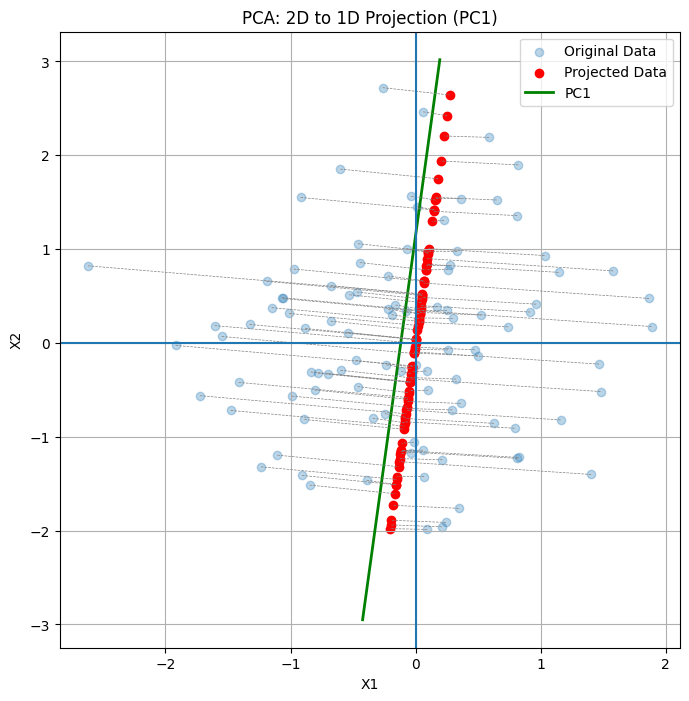

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Step 1: Create sample 2D data
np.random.seed(42)
X = np.random.randn(100, 2)

# Step 2: Apply PCA (reduce to 1 dimension)
pca = PCA(n_components=1)
X_pca = pca.fit_transform(X)

# Step 3: Get PC1 direction (eigenvector)
pc1 = pca.components_[0]

# Step 4: Project points back to 2D (for visualization)
X_projected = X_pca @ pc1.reshape(1, -1)

# Step 5: Plot everything
plt.figure(figsize=(8, 8))

# Original points
plt.scatter(X[:, 0], X[:, 1], alpha=0.3, label='Original Data')

# Projected points (on PC1)
plt.scatter(X_projected[:, 0], X_projected[:, 1], color='red', label='Projected Data')

# Draw PC1 line
mean = np.mean(X, axis=0)
line = np.array([mean - 3*pc1, mean + 3*pc1])
plt.plot(line[:, 0], line[:, 1], color='green', linewidth=2, label='PC1')

# Draw projection lines
for i in range(len(X)):
    plt.plot([X[i, 0], X_projected[i, 0]],
             [X[i, 1], X_projected[i, 1]],
             color='gray', linestyle='--', linewidth=0.5)

plt.axhline(0)
plt.axvline(0)
plt.legend()
plt.title("PCA: 2D to 1D Projection (PC1)")
plt.xlabel("X1")
plt.ylabel("X2")
plt.grid()

plt.show()

### ===================================================

# 1. Import Necessary libraries

In [1]:
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,confusion_matrix

# 2. Import Data

In [2]:
breast_cancer = load_breast_cancer()

In [3]:
breast_cancer_df = pd.DataFrame(data = breast_cancer.data,columns=breast_cancer.feature_names)
breast_cancer_df['Target'] = breast_cancer.target
breast_cancer_df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


# 3. Model Building

In [4]:
X = breast_cancer_df.drop('Target',axis = 1)
y = breast_cancer_df[['Target']]

In [7]:
X.shape,y.shape

((569, 30), (569, 1))

In [5]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20,stratify=y,random_state=12)

In [46]:
X_train.shape,y_train.shape

((455, 30), (455, 1))

In [47]:
X_test.shape,y_test.shape

((114, 30), (114, 1))

# 4. Model Training

In [6]:
dt_model = DecisionTreeClassifier()

In [7]:
%%time
dt_model.fit(X_train,y_train)

CPU times: total: 15.6 ms
Wall time: 18 ms


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


# 5. Model Testing || 6. Model Evaluation

### Training data

In [8]:
y_train_pred = dt_model.predict(X_train)

print('Accuracy Score  : ',accuracy_score(y_train,y_train_pred))
print('Confusion Matrix:\n',confusion_matrix(y_train,y_train_pred))

Accuracy Score  :  1.0
Confusion Matrix:
 [[170   0]
 [  0 285]]


### Test data

In [9]:
y_test_pred = dt_model.predict(X_test)

print('Accuracy Score  : ',accuracy_score(y_test,y_test_pred))
print('Confusion Matrix:\n',confusion_matrix(y_test,y_test_pred))

Accuracy Score  :  0.8771929824561403
Confusion Matrix:
 [[36  6]
 [ 8 64]]


# ============================================================

# APPLYING PCA FOR REDUCING DIMENSIONS

In [10]:
from sklearn.preprocessing import StandardScaler
std_scaler = StandardScaler()
std_scaler = std_scaler.fit_transform(X)

X_scaled = pd.DataFrame(data = std_scaler,columns=X_train.columns)
X_scaled

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,2.110995,0.721473,2.060786,2.343856,1.041842,0.219060,1.947285,2.320965,-0.312589,-0.931027,...,1.901185,0.117700,1.752563,2.015301,0.378365,-0.273318,0.664512,1.629151,-1.360158,-0.709091
565,1.704854,2.085134,1.615931,1.723842,0.102458,-0.017833,0.693043,1.263669,-0.217664,-1.058611,...,1.536720,2.047399,1.421940,1.494959,-0.691230,-0.394820,0.236573,0.733827,-0.531855,-0.973978
566,0.702284,2.045574,0.672676,0.577953,-0.840484,-0.038680,0.046588,0.105777,-0.809117,-0.895587,...,0.561361,1.374854,0.579001,0.427906,-0.809587,0.350735,0.326767,0.414069,-1.104549,-0.318409
567,1.838341,2.336457,1.982524,1.735218,1.525767,3.272144,3.296944,2.658866,2.137194,1.043695,...,1.961239,2.237926,2.303601,1.653171,1.430427,3.904848,3.197605,2.289985,1.919083,2.219635


In [72]:
from sklearn.decomposition import PCA
pca_decomposition = PCA(n_components=2,random_state=12)
X_transformed     = pca_decomposition.fit_transform(X_scaled) #PCA expects data in common scale.
X_transformed_df  = pd.DataFrame(data = X_transformed)
X_transformed_df.columns = ['X1','X2']#,'X3','X4']
X_transformed_df

,X1,X2
0,9.192837,1.948583
1,2.387802,-3.768172
2,5.733896,-1.075174
3,7.122953,10.275589
4,3.935302,-1.948072
...,...,...
564,6.439315,-3.576817
565,3.793382,-3.584048
566,1.256179,-1.902297
567,10.374794,1.672010


In [73]:
pca_explained_ratio = pca_decomposition.explained_variance_ratio_
pca_explained_ratio

array([0.44272026, 0.18971182])

In [74]:
import numpy as np
np.cumsum(np.round(a = pca_explained_ratio,decimals=4)*100)

array([44.27, 63.24])

## 3. Model Building

In [75]:
X_train,X_test,y_train,y_test = train_test_split(X_transformed_df,y,test_size=0.20,stratify=y,random_state=12)

In [76]:
X_train.shape,y_train.shape

((455, 2), (455,))

In [77]:
X_test.shape,y_test.shape

((114, 2), (114,))

## 4. Model Training

In [78]:
dt_model = DecisionTreeClassifier()

In [79]:
%%time
dt_model.fit(X_train,y_train)

CPU times: total: 0 ns
Wall time: 4.15 ms


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


# 5. Model Testing || 6. Model Evaluation

### Training data

In [80]:
y_train_pred = dt_model.predict(X_train)

print('Accuracy Score  : ',accuracy_score(y_train,y_train_pred))
print('Confusion Matrix:\n',confusion_matrix(y_train,y_train_pred))

Accuracy Score  :  1.0
Confusion Matrix:
 [[170   0]
 [  0 285]]


### Test data

In [81]:
y_test_pred = dt_model.predict(X_test)

print('Accuracy Score  : ',accuracy_score(y_test,y_test_pred))
print('Confusion Matrix:\n',confusion_matrix(y_test,y_test_pred))

Accuracy Score  :  0.8596491228070176
Confusion Matrix:
 [[38  4]
 [12 60]]


# VISUALIZATION

In [20]:
from matplotlib import pyplot as plt

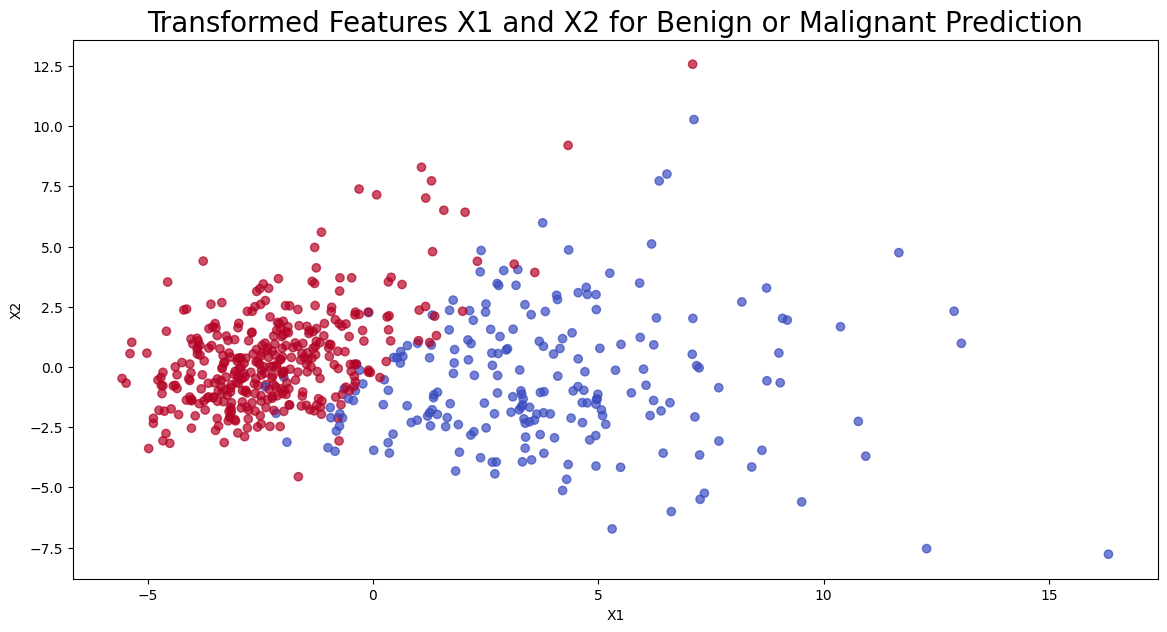

In [86]:
plt.figure(figsize=(14,7))
plt.scatter(X_transformed_df['X1'],X_transformed_df['X2'],c=y,cmap='coolwarm', alpha=0.7)
plt.title('Transformed Features X1 and X2 for Benign or Malignant Prediction',size = 20)
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()

### Turn this to 1D...

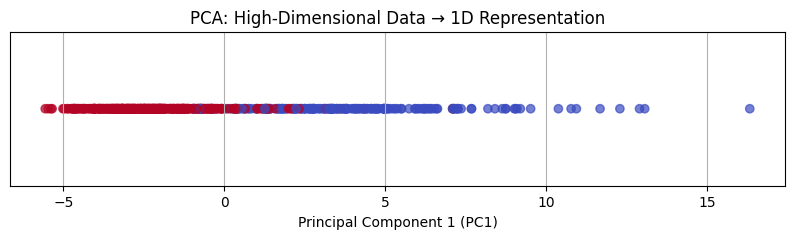

In [48]:
data = load_breast_cancer()
X = data.data
y = data.target 

# Step 2: Standardize (VERY IMPORTANT for PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 3: Apply PCA (reduce to 1 dimension)
pca = PCA(n_components=1)
X_pca = pca.fit_transform(X_scaled)

# Step 4: 1D Visualization (Main one you want)
plt.figure(figsize=(10, 2))

plt.scatter(X_pca, np.zeros_like(X_pca), c=y, cmap='coolwarm', alpha=0.7)

plt.yticks([])  # remove Y-axis
plt.xlabel("Principal Component 1 (PC1)")
plt.title("PCA: High-Dimensional Data → 1D Representation")

plt.grid()
plt.show()

### =================================================

# THE END!!

### PCA Works only if....

In [66]:
breast_cancer_df.corr().round()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Target
mean radius,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,-0.0,...,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,-1.0
mean texture,0.0,1.0,0.0,0.0,-0.0,0.0,0.0,0.0,0.0,-0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.0
mean perimeter,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,-0.0,...,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,-1.0
mean area,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,-0.0,...,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,-1.0
mean smoothness,0.0,-0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,-0.0
mean compactness,1.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,...,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,-1.0
mean concavity,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,...,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,-1.0
mean concave points,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,...,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,-1.0
mean symmetry,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.0
mean fractal dimension,-0.0,-0.0,-0.0,-0.0,1.0,1.0,0.0,0.0,0.0,1.0,...,-0.0,-0.0,-0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
